# Automotive Engine Health Analysis

Dataset source: https://www.kaggle.com/datasets/parvmodi/automotive-vehicles-engine-health-dataset/data

# Import libraries

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset

In [7]:
data = pd.read_csv("./data/engine_data.csv")

In [24]:
print("Dataset Shape: ", data.shape)
print("Basic Data Information")
data.info()

Dataset Shape:  (19535, 7)
Basic Data Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19535 entries, 0 to 19534
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Engine rpm        19535 non-null  int64  
 1   Lub oil pressure  19535 non-null  float64
 2   Fuel pressure     19535 non-null  float64
 3   Coolant pressure  19535 non-null  float64
 4   lub oil temp      19535 non-null  float64
 5   Coolant temp      19535 non-null  float64
 6   Engine Condition  19535 non-null  int64  
dtypes: float64(5), int64(2)
memory usage: 1.0 MB


In [26]:
display(data.head(5))

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
0,700,2.493592,11.790927,3.178981,84.144163,81.632187,1
1,876,2.941606,16.193866,2.464504,77.640934,82.445724,0
2,520,2.961746,6.553147,1.064347,77.752266,79.645777,1
3,473,3.707835,19.510172,3.727455,74.129907,71.774629,1
4,619,5.672919,15.738871,2.052251,78.396989,87.000225,0


# Initial observation
- Dataset consists of 19535 records, 7 Columns
- "Engine Condition" is also included, and hence the dataset can be used for Supervised learning
- Totally 6 features: "Engine rpm", "Lub oil pressure", "Fuel pressure", "Coolant pressure", "lub oil temp", "Coolant temp"
- Data set basic information shows no missing data. Will be verified to ensure data sanctity

# Exploratory Data analysis

## Data quality assessment
- Null or/and NaN
- Duplicate entry
- Statistical summary

In [30]:
data.isnull().sum()

Engine rpm          0
Lub oil pressure    0
Fuel pressure       0
Coolant pressure    0
lub oil temp        0
Coolant temp        0
Engine Condition    0
dtype: int64

In [32]:
data.duplicated().sum()

0

There are no missing data or duplicate records.

In [35]:
data.describe()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
count,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000
mean,791.239263,3.303775,6.655615,2.335369,77.643420,78.427433,0.630509
std,267.611193,1.021643,2.761021,1.036382,3.110984,6.206749,0.482679
min,61.000000,0.003384,0.003187,0.002483,71.321974,61.673325,0.000000
25%,593.000000,2.518815,4.916886,1.600466,75.725990,73.895421,0.000000
50%,746.000000,3.162035,6.201720,2.166883,76.817350,78.346662,1.000000
75%,934.000000,4.055272,7.744973,2.848840,78.071691,82.915411,1.000000
max,2239.000000,7.265566,21.138326,7.478505,89.580796,195.527912,1.000000


## Visualize Data distribution

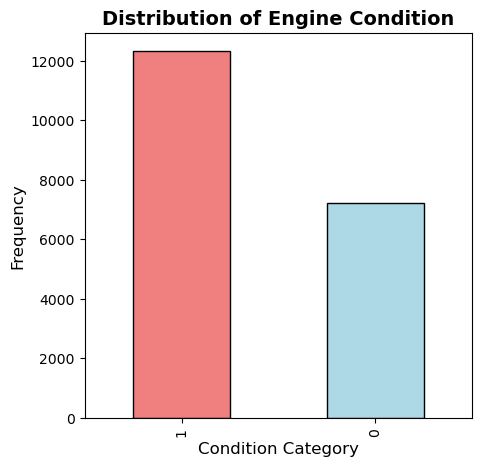

In [60]:
# Target Varible distribution

plt.figure(figsize = (5,5))

# Plot the bar chart
data["Engine Condition"].value_counts().plot(
    kind='bar',
    color=['lightcoral', 'lightblue'],
    edgecolor='black'
)

# Add titles and labels
plt.title("Distribution of Engine Condition", fontsize=14, fontweight='bold')
plt.xlabel("Condition Category", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.show()


## Outlier check
- Z-Score method
- IQR method (box plot)